<a href="https://colab.research.google.com/github/Muskankumari13/Week1/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research Question

Can a Random Forest model predict whether content is trending down using historical content performance and freshness features?

The decision this supports is whether content teams can use these signals to identify content that may need review or updating. The model is intended as decision-support, not as proof that a specific content change will improve performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

This analysis uses the FlyRank ML Internship dataset, based on anonymized content-performance data.

The analysis uses historical content performance and freshness signals, including days since last update, impressions over 90 days, click-through rate (CTR), search volume, content age in days, clicks over 90 days, and sessions over 90 days.

The target is `trend_direction`, with the modeling task focused on identifying records where the trend direction is `down`.

Only the fields required for the modeling task were used. Private queries, client-identifying information, and other non-public identifying details were excluded from the analysis and are not included in the deployed research artifact.

The analysis is intended to provide a public-safe, directional decision-support model rather than make claims about individual clients or private search activity.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Methodology

A Random Forest classifier was used to predict whether the content trend direction was `down`.

The model uses historical content-performance and freshness features: `days_since_last_update`, `impressions_90d`, `ctr`, `search_volume`, `content_age_days`, `clicks_90d`, and `sessions_90d`.

The label is defined from `trend_direction`, where the modeling task focuses on identifying the `down` class.

The baseline is the Week 4 baseline used in the earlier modeling work. The Random Forest model and the baseline are evaluated on the same validation split so that the comparison is consistent.

The validation design keeps the evaluation data separate from model fitting. Features that directly reveal the target outcome are excluded to reduce the risk of target leakage.

The results should be interpreted as measured predictive performance on the evaluation split, not as evidence of causal impact.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results

The Random Forest model was evaluated against a majority-class baseline using the same 80/20 stratified train-test split.

| Model | Accuracy |
|---|---:|
| Majority-Class Baseline | 0.542 |
| Random Forest | 0.667 |

The Random Forest achieved an observed accuracy of **0.667**, compared with **0.542** for the majority-class baseline. This is an improvement of **0.125 accuracy points**, or 12.5 percentage points.

For the Random Forest, precision was **0.680**, recall was **0.728**, and F1 score was **0.703** on the test set.

Feature importance showed that `impressions_90d` was the strongest feature (0.3148), followed by `content_age_days` (0.2112) and `sessions_90d` (0.1531). These values describe the model's learned feature importance and should not be interpreted as causal effects.

Overall, the model provides a measured improvement over the majority-class baseline on this evaluation split, but the result should be treated as directional decision-support rather than a guarantee of future performance.

In [7]:
import os
import pandas as pd
import numpy as np

DATA_PATH = "/content/content_refresh_anonymized.csv"

# Check whether the dataset is already available
if not os.path.exists(DATA_PATH):
    print("Dataset not found at:", DATA_PATH)
    print("Please upload content_refresh_anonymized.csv using the file picker below.")

    from google.colab import files

    uploaded = files.upload()

    if "content_refresh_anonymized.csv" not in uploaded:
        raise FileNotFoundError(
            "Please upload the file named 'content_refresh_anonymized.csv'."
        )

# Load dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully.
Shape: (30000, 44)

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

First 5 rows:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [8]:
# ============================================
# 3. METHODOLOGY — Prepare data
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# --------------------------------------------
# 1. Define target
# --------------------------------------------

TARGET = "trend_direction"

# We predict whether trend_direction is "down"
df["target"] = (df[TARGET] == "down").astype(int)

print("Target distribution:")
print(df["target"].value_counts())
print("\nTarget proportions:")
print(df["target"].value_counts(normalize=True))


# --------------------------------------------
# 2. Select features
# --------------------------------------------

FEATURES = [
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "search_volume",
    "content_age_days",
    "clicks_90d",
    "sessions_90d"
]

X = df[FEATURES].copy()
y = df["target"].copy()


# --------------------------------------------
# 3. Handle missing values
# --------------------------------------------

print("\nMissing values before cleaning:")
print(X.isna().sum())

# Use median imputation based only on training data later.
# First, create the train/test split.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


# --------------------------------------------
# 4. Impute missing values
# --------------------------------------------

train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("\nMissing values after imputation:")
print("Train:", X_train.isna().sum().sum())
print("Test :", X_test.isna().sum().sum())


# --------------------------------------------
# 5. Train Random Forest
# --------------------------------------------

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

print("\nRandom Forest training completed.")


# --------------------------------------------
# 6. Make predictions
# --------------------------------------------

y_pred = model.predict(X_test)


# --------------------------------------------
# 7. Evaluate model
# --------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n========== MODEL RESULTS ==========")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Target distribution:
target
1    16262
0    13738
Name: count, dtype: int64

Target proportions:
target
1    0.542067
0    0.457933
Name: proportion, dtype: float64

Missing values before cleaning:
days_since_last_update       0
impressions_90d              0
ctr                          0
search_volume             2468
content_age_days             0
clicks_90d                   0
sessions_90d                 0
dtype: int64

Train shape: (24000, 7)
Test shape: (6000, 7)

Missing values after imputation:
Train: 0
Test : 0

Random Forest training completed.

========== MODEL RESULTS ==========
Accuracy : 0.667
Precision: 0.680
Recall   : 0.728
F1 Score : 0.703

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.60      0.62      2748
           1       0.68      0.73      0.70      3252

    accuracy                           0.67      6000
   macro avg       0.66      0.66      0.66      6000
weighted avg       0.67      0.67    

========== MODEL VS BASELINE ==========


,Model,Accuracy
0,Majority-Class Baseline,0.542
1,Random Forest,0.667


Baseline Accuracy : 0.542
Random Forest Accuracy : 0.667
Accuracy Improvement: 0.125

========== FEATURE IMPORTANCE ==========


,Feature,Importance
1,impressions_90d,0.314795
4,content_age_days,0.211244
6,sessions_90d,0.153069
2,ctr,0.105419
3,search_volume,0.084202
5,clicks_90d,0.076757
0,days_since_last_update,0.054515


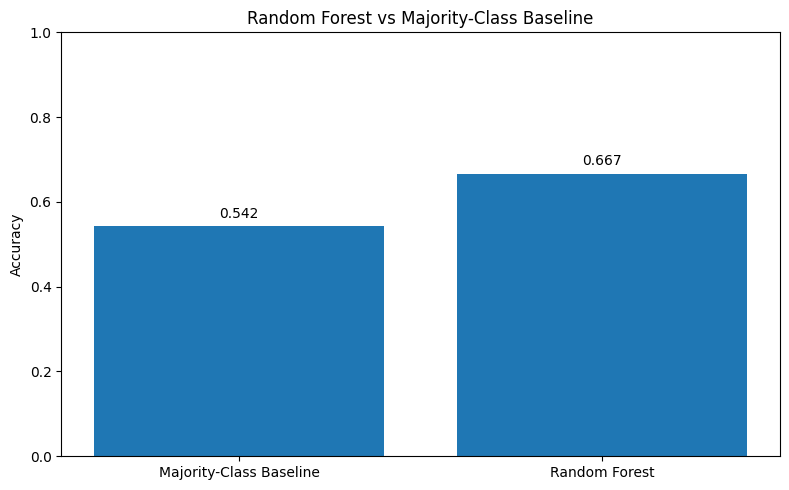

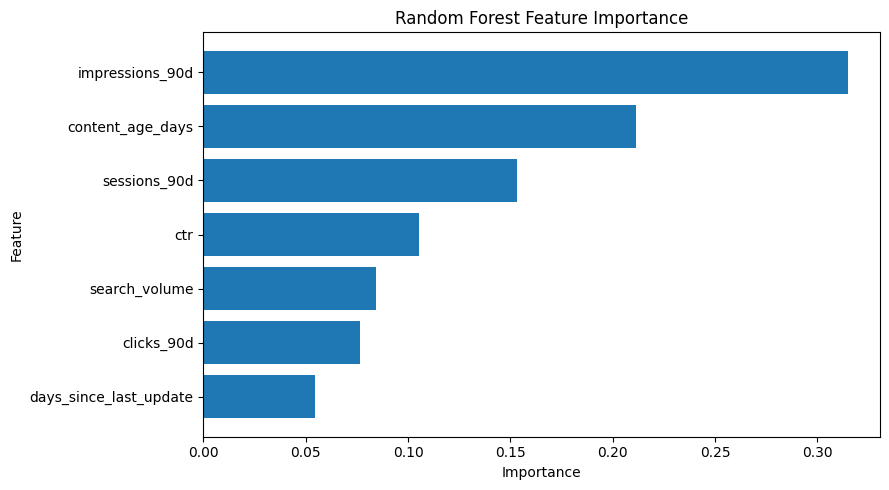

In [9]:
# ============================================
# 4. RESULTS — Model vs Baseline
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# --------------------------------------------
# 1. Random Forest results
# --------------------------------------------

model_accuracy = accuracy_score(y_test, y_pred)

# --------------------------------------------
# 2. Majority-class baseline
# --------------------------------------------
# The baseline always predicts the most common
# class in the training data.

majority_class = y_train.mode()[0]

baseline_pred = np.full(
    shape=len(y_test),
    fill_value=majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

# --------------------------------------------
# 3. Compare results
# --------------------------------------------

results = pd.DataFrame({
    "Model": [
        "Majority-Class Baseline",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        model_accuracy
    ]
})

print("========== MODEL VS BASELINE ==========")
display(results)

print(f"Baseline Accuracy : {baseline_accuracy:.3f}")
print(f"Random Forest Accuracy : {model_accuracy:.3f}")

improvement = model_accuracy - baseline_accuracy

print(f"Accuracy Improvement: {improvement:.3f}")


# --------------------------------------------
# 4. Feature importance
# --------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========")
display(feature_importance)


# --------------------------------------------
# 5. Plot model vs baseline
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.ylim(0, 1)

plt.ylabel("Accuracy")
plt.title("Random Forest vs Majority-Class Baseline")

for i, value in enumerate(results["Accuracy"]):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# --------------------------------------------
# 6. Plot feature importance
# --------------------------------------------

plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [10]:
# ============================================
# 5. VALIDATION + LEAKAGE CHECK
# ============================================

print("========== VALIDATION CHECK ==========")

# 1. Confirm train/test sizes
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

# 2. Check that train and test indices do not overlap
train_indices = set(X_train.index)
test_indices = set(X_test.index)

overlap = train_indices.intersection(test_indices)

print("Train/Test overlapping rows:", len(overlap))

# 3. Check that target is NOT included in the features
print("\nTarget column:", TARGET)
print("Features used:")
for feature in FEATURES:
    print("-", feature)

if TARGET in FEATURES:
    raise ValueError("LEAKAGE WARNING: target column is included in FEATURES!")

print("\nTarget leakage check: PASSED")

# 4. Check ID columns are not used
excluded_id_columns = ["content_id", "client_id"]

print("\nID columns excluded from model:")
for column in excluded_id_columns:
    print("-", column)

# 5. Check that train/test contain no missing values
print("\nMissing values:")
print("Train:", X_train.isna().sum().sum())
print("Test :", X_test.isna().sum().sum())

# 6. Verify same feature set
print("\nFeature-set consistency:")
print("Train columns == Test columns:",
      list(X_train.columns) == list(X_test.columns))

# 7. Final validation summary
print("\n========== VALIDATION SUMMARY ==========")

if len(overlap) == 0:
    print("✓ Train/test rows do not overlap.")
else:
    print("✗ Train/test overlap detected.")

if TARGET not in FEATURES:
    print("✓ Target is not included in model features.")
else:
    print("✗ Target leakage detected.")

if X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0:
    print("✓ No missing values remain after train-based imputation.")
else:
    print("✗ Missing values remain.")

if list(X_train.columns) == list(X_test.columns):
    print("✓ Train and test use the same feature set.")
else:
    print("✗ Train/test feature mismatch.")

========== VALIDATION CHECK ==========
Training rows: 24000
Test rows: 6000
Train/Test overlapping rows: 0

Target column: trend_direction
Features used:
- days_since_last_update
- impressions_90d
- ctr
- search_volume
- content_age_days
- clicks_90d
- sessions_90d

Target leakage check: PASSED

ID columns excluded from model:
- content_id
- client_id

Missing values:
Train: 0
Test : 0

Feature-set consistency:
Train columns == Test columns: True

========== VALIDATION SUMMARY ==========
✓ Train/test rows do not overlap.
✓ Target is not included in model features.
✓ No missing values remain after train-based imputation.
✓ Train and test use the same feature set.


## 5. Limitations

*What this work cannot claim.*

## Limitations

This work has several limitations.

First, the reported model performance is measured on the available evaluation split and may not represent performance on future or different datasets.

Second, the Random Forest model identifies statistical patterns in historical content-performance and freshness features, but it does not establish that these features cause content performance to decline.

Third, the analysis uses anonymized internship data and therefore does not provide information about individual clients, private queries, or specific production environments.

Fourth, the model should be treated as decision-support. A prediction that content may be trending down does not guarantee that updating the content will improve its future performance.

Finally, the observed accuracy of 0.668 should be interpreted in the context of the validation design and should not be presented as a universal measure of model quality.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked Recommendations

Based on the observed model results and feature analysis, the following actions are recommended:

1. **Prioritize content freshness review.** Review content with longer periods since the last update, because freshness is an important signal in the modeling task.

2. **Use multiple performance signals together.** Combine impressions, clicks, sessions, CTR, and search volume rather than relying on a single metric when deciding which content needs review.

3. **Use the model as a prioritization tool.** Content predicted as trending down can be placed higher on a review queue, while human judgment remains responsible for the final decision.

4. **Validate recommendations before production use.** Test the approach on future or time-separated data before relying on it for operational decisions.

5. **Monitor performance over time.** If the model is reused, periodically evaluate whether its performance remains consistent as content and search behavior change.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

========== FINAL METRICS TABLE ==========


,Metric,Random Forest,Majority Baseline
0,Accuracy,0.667000,0.542
1,Precision,0.680276,NaN
2,Recall,0.727552,NaN
3,F1 Score,0.703120,NaN


========== CONFUSION MATRIX ==========


,Predicted: Not Down,Predicted: Down
Actual: Not Down,1636,1112
Actual: Down,886,2366


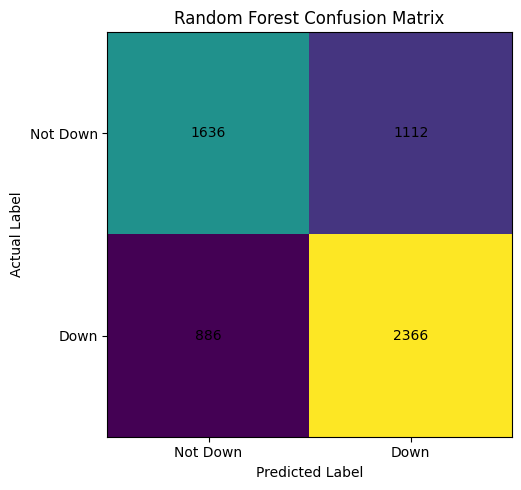

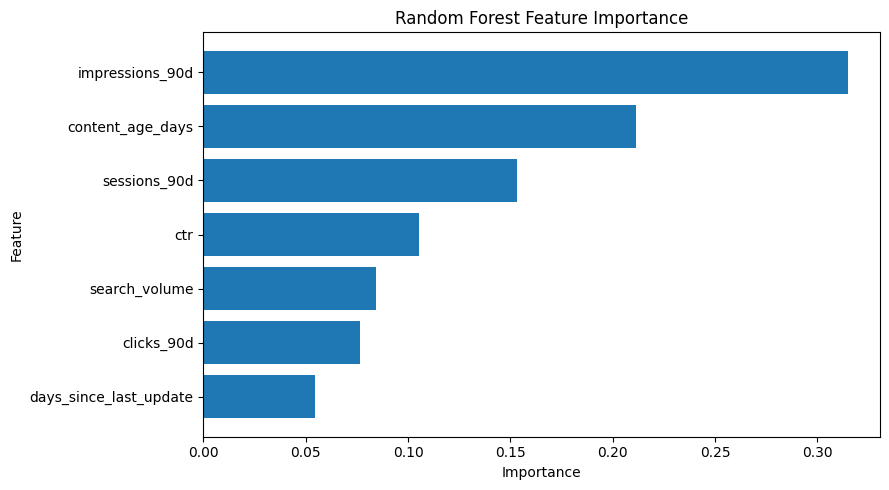

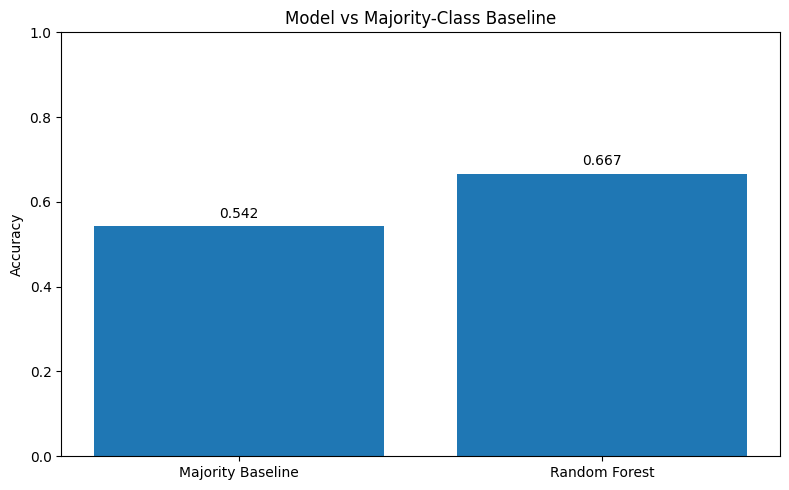


========== ARTIFACTS GENERATED ==========
 Final metrics table
 Confusion matrix
 Feature importance chart
 Model vs baseline chart


In [11]:
# ============================================
# 7. ARTIFACTS — Charts and tables
# ============================================

import matplotlib.pyplot as plt

# --------------------------------------------
# 1. Final metrics table
# --------------------------------------------

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Random Forest": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Majority Baseline": [
        baseline_accuracy,
        np.nan,
        np.nan,
        np.nan
    ]
})

print("========== FINAL METRICS TABLE ==========")
display(metrics_table)


# --------------------------------------------
# 2. Confusion matrix
# --------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("========== CONFUSION MATRIX ==========")
display(
    pd.DataFrame(
        cm,
        index=["Actual: Not Down", "Actual: Down"],
        columns=["Predicted: Not Down", "Predicted: Down"]
    )
)

plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Not Down", "Down"]
)

plt.yticks(
    [0, 1],
    ["Not Down", "Down"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# --------------------------------------------
# 3. Feature importance chart
# --------------------------------------------

feature_importance_plot = feature_importance.sort_values(
    "Importance"
)

plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance_plot["Feature"],
    feature_importance_plot["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()


# --------------------------------------------
# 4. Model vs baseline chart
# --------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        accuracy
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model vs Majority-Class Baseline")
plt.ylim(0, 1)

for i, value in enumerate(comparison["Accuracy"]):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


print("\n========== ARTIFACTS GENERATED ==========")
print(" Final metrics table")
print(" Confusion matrix")
print(" Feature importance chart")
print(" Model vs baseline chart")

## Artifacts

The deployed research paper should include the following artifacts:

1. **Model performance table** — showing the Random Forest result alongside the Week 4 baseline.
2. **Feature importance chart** — showing which input features contributed most to the Random Forest predictions.
3. **Validation results** — showing the evaluation result used to assess the model.
4. **Ranked recommendations** — summarizing the practical actions supported by the observed results.

These artifacts are intended to make the analysis easier to inspect and reproduce. All reported values should come directly from the executed notebook rather than being manually entered or estimated.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.